# Hindi → Marathi Neural Machine Translation
## BERT Encoder (Hindi) + GPT Decoder (Marathi) with Cross-Attention

## 1. Imports & Setup

In [48]:
import os, math, time
from dataclasses import dataclass
from typing import Optional

import numpy as np
import sentencepiece as spm
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

device = (
    "cuda"  if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {device}")
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)

Device: cuda


## 2. Shared Building Blocks (RMSNorm, RoPE, GQA)

In [ ]:
#  RMSNorm
class RMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        rms = x.pow(2).mean(-1, keepdim=True).add(self.eps).rsqrt()
        return x * rms * self.weight


#  RoPE 
def precompute_rope_freqs(head_dim: int, max_seq_len: int,
                          base: float = 10_000.0, device=None):
    assert head_dim % 2 == 0
    half = head_dim // 2
    inv_freq = 1.0 / (base ** (torch.arange(0, half, dtype=torch.float32, device=device) / half))
    t = torch.arange(max_seq_len, dtype=torch.float32, device=device)
    freqs = torch.outer(t, inv_freq)
    return freqs.cos(), freqs.sin()


def apply_rope(x, cos, sin):
    """x: (B, H, T, D)"""
    B, H, T, D = x.shape
    half = D // 2
    x1, x2 = x[..., :half], x[..., half:]
    c = cos[:T].unsqueeze(0).unsqueeze(0)
    s = sin[:T].unsqueeze(0).unsqueeze(0)
    return torch.cat([x1 * c - x2 * s, x2 * c + x1 * s], dim=-1)


#  MLP 
class MLP(nn.Module):
    def __init__(self, n_embd: int):
        super().__init__()
        self.c_fc   = nn.Linear(n_embd, 4 * n_embd, bias=False)
        self.gelu   = nn.GELU(approximate='tanh')
        self.c_proj = nn.Linear(4 * n_embd, n_embd, bias=False)
        self.c_proj.SCALE_INIT = 1

    def forward(self, x):
        return self.c_proj(self.gelu(self.c_fc(x)))

## 3. Encoder: Hindi BERT (Bidirectional)



In [ ]:
@dataclass
class BERTConfig:
    block_size : int   = 128
    vocab_size : int   = 20000
    n_layer    : int   = 4
    n_head     : int   = 4
    n_kv_head  : int   = 2
    n_embd     : int   = 768
    rope_base  : float = 10_000.0


class BidirectionalGQA(nn.Module):
    
    def __init__(self, config: BERTConfig):
        super().__init__()
        self.n_head    = config.n_head
        self.n_kv_head = config.n_kv_head
        self.n_rep     = config.n_head // config.n_kv_head
        self.head_dim  = config.n_embd // config.n_head

        self.q_proj  = nn.Linear(config.n_embd, config.n_head    * self.head_dim, bias=False)
        self.kv_proj = nn.Linear(config.n_embd, config.n_kv_head * self.head_dim * 2, bias=False)
        self.o_proj  = nn.Linear(config.n_embd, config.n_embd, bias=False)
        self.o_proj.SCALE_INIT = 1

    def forward(self, x, cos, sin, key_padding_mask=None):
        B, T, C = x.shape
        q = self.q_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        kv = self.kv_proj(x).view(B, T, 2, self.n_kv_head, self.head_dim)
        k, v = kv[:, :, 0].transpose(1, 2), kv[:, :, 1].transpose(1, 2)

        q = apply_rope(q, cos, sin)
        k = apply_rope(k, cos, sin)

        # Expand KV heads to match Q heads
        k = k.repeat_interleave(self.n_rep, dim=1)
        v = v.repeat_interleave(self.n_rep, dim=1)

        # NO causal mask — full bidirectional attention
        attn_mask = None
        if key_padding_mask is not None:
            # key_padding_mask: (B, T) bool, True where padding
            attn_mask = key_padding_mask.unsqueeze(1).unsqueeze(2)  # (B,1,1,T)
            attn_mask = attn_mask.expand(B, self.n_head, T, T)
            attn_mask = attn_mask.masked_fill(attn_mask, float('-inf'))

        y = F.scaled_dot_product_attention(q, k, v, attn_mask=attn_mask, is_causal=False)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.o_proj(y)


class BERTBlock(nn.Module):
    def __init__(self, config: BERTConfig):
        super().__init__()
        self.ln_1 = RMSNorm(config.n_embd)
        self.attn = BidirectionalGQA(config)
        self.ln_2 = RMSNorm(config.n_embd)
        self.mlp  = MLP(config.n_embd)

    def forward(self, x, cos, sin, key_padding_mask=None):
        x = x + self.attn(self.ln_1(x), cos, sin, key_padding_mask)
        x = x + self.mlp(self.ln_2(x))
        return x


class HindiBERT(nn.Module):
    

    def __init__(self, config: BERTConfig):
        super().__init__()
        self.config = config
        self.encoder = nn.ModuleDict(dict(
            wte   = nn.Embedding(config.vocab_size, config.n_embd),
            h     = nn.ModuleList([BERTBlock(config) for _ in range(config.n_layer)]),
            rms_f = RMSNorm(config.n_embd),
        ))
        self._rope_cos = self._rope_sin = self._rope_device = None
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            std = 0.02 * (2 * self.config.n_layer) ** -0.5 if hasattr(m, 'SCALE_INIT') else 0.02
            nn.init.normal_(m.weight, 0.0, std)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding): nn.init.normal_(m.weight, 0.0, 0.02)
        elif isinstance(m, RMSNorm):     nn.init.ones_(m.weight)

    def _get_rope(self, device):
        if self._rope_cos is None or self._rope_device != device:
            hd = self.config.n_embd // self.config.n_head
            self._rope_cos, self._rope_sin = precompute_rope_freqs(
                hd, self.config.block_size, self.config.rope_base, device)
            self._rope_device = device
        return self._rope_cos, self._rope_sin

    def encode(self, idx: torch.Tensor,
               key_padding_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        
        B, T = idx.shape
        x = self.encoder.wte(idx)
        cos, sin = self._get_rope(idx.device)
        for block in self.encoder.h:
            x = block(x, cos, sin, key_padding_mask)
        return self.encoder.rms_f(x)  # (B, T_src, n_embd)

    # Alias for compatibility
    def forward(self, idx, key_padding_mask=None):
        return self.encode(idx, key_padding_mask)

## 4. Decoder: Marathi GPT (Causal Self-Attention + Cross-Attention)



In [ ]:
@dataclass
class GPTConfig:
    block_size : int   = 128
    vocab_size : int   = 20000
    n_layer    : int   = 4
    n_head     : int   = 4
    n_kv_head  : int   = 2
    n_embd     : int   = 768   
    rope_base  : float = 10_000.0


class CausalGQA(nn.Module):
    """Causal (masked) GQA for decoder self-attention."""
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.n_head    = config.n_head
        self.n_kv_head = config.n_kv_head
        self.n_rep     = config.n_head // config.n_kv_head
        self.head_dim  = config.n_embd // config.n_head

        self.q_proj  = nn.Linear(config.n_embd, config.n_head    * self.head_dim, bias=False)
        self.kv_proj = nn.Linear(config.n_embd, config.n_kv_head * self.head_dim * 2, bias=False)
        self.o_proj  = nn.Linear(config.n_embd, config.n_embd, bias=False)
        self.o_proj.SCALE_INIT = 1

    def forward(self, x, cos, sin):
        B, T, C = x.shape
        q = self.q_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        kv = self.kv_proj(x).view(B, T, 2, self.n_kv_head, self.head_dim)
        k, v = kv[:, :, 0].transpose(1, 2), kv[:, :, 1].transpose(1, 2)

        q = apply_rope(q, cos, sin)
        k = apply_rope(k, cos, sin)

        k = k.repeat_interleave(self.n_rep, dim=1)
        v = v.repeat_interleave(self.n_rep, dim=1)

        # is_causal=True enforces the autoregressive mask
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return self.o_proj(y.transpose(1, 2).contiguous().view(B, T, C))


class CrossAttention(nn.Module):
   
    def __init__(self, config: GPTConfig, encoder_dim: int):
        super().__init__()
        self.n_head   = config.n_head
        self.head_dim = config.n_embd // config.n_head
        n_embd        = config.n_embd

        # Query from decoder hidden state
        self.q_proj  = nn.Linear(n_embd, n_embd, bias=False)
        # Key and Value from encoder output (may differ in dim, handle with projection)
        self.k_proj  = nn.Linear(encoder_dim, n_embd, bias=False)
        self.v_proj  = nn.Linear(encoder_dim, n_embd, bias=False)
        self.o_proj  = nn.Linear(n_embd, n_embd, bias=False)
        self.o_proj.SCALE_INIT = 1

    def forward(self, x: torch.Tensor, encoder_out: torch.Tensor,
                src_key_padding_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
       
        B, T_tgt, C = x.shape
        T_src = encoder_out.size(1)

        q = self.q_proj(x).view(B, T_tgt, self.n_head, self.head_dim).transpose(1, 2)
        k = self.k_proj(encoder_out).view(B, T_src, self.n_head, self.head_dim).transpose(1, 2)
        v = self.v_proj(encoder_out).view(B, T_src, self.n_head, self.head_dim).transpose(1, 2)

        # Mask out padding positions in the Hindi source
        attn_bias = None
        if src_key_padding_mask is not None:
            # (B, 1, 1, T_src) → broadcast over all heads and query positions
            attn_bias = src_key_padding_mask.unsqueeze(1).unsqueeze(2).float()
            attn_bias = attn_bias * -1e9  # large negative → near-zero attention

        y = F.scaled_dot_product_attention(q, k, v, attn_mask=attn_bias, is_causal=False)
        y = y.transpose(1, 2).contiguous().view(B, T_tgt, C)
        return self.o_proj(y)


class DecoderBlock(nn.Module):
    
    def __init__(self, config: GPTConfig, encoder_dim: int):
        super().__init__()
        self.ln_1        = RMSNorm(config.n_embd)
        self.self_attn   = CausalGQA(config)                          # step 1
        self.ln_2        = RMSNorm(config.n_embd)
        self.cross_attn  = CrossAttention(config, encoder_dim)         # step 2
        self.ln_3        = RMSNorm(config.n_embd)
        self.mlp         = MLP(config.n_embd)                          # step 3

    def forward(self, x, cos, sin, encoder_out, src_key_padding_mask=None):
        x = x + self.self_attn(self.ln_1(x), cos, sin)
        x = x + self.cross_attn(self.ln_2(x), encoder_out, src_key_padding_mask)
        x = x + self.mlp(self.ln_3(x))
        return x


class MarathiDecoder(nn.Module):
    """Marathi GPT decoder with cross-attention over Hindi encoder output."""

    def __init__(self, config: GPTConfig, encoder_dim: int = 768):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte   = nn.Embedding(config.vocab_size, config.n_embd),
            h     = nn.ModuleList([DecoderBlock(config, encoder_dim) for _ in range(config.n_layer)]),
            rms_f = RMSNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        # Weight tying: decoder embedding ↔ lm_head
        self.transformer.wte.weight = self.lm_head.weight

        self._rope_cos = self._rope_sin = self._rope_device = None
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            std = 0.02 * (2 * self.config.n_layer) ** -0.5 if hasattr(m, 'SCALE_INIT') else 0.02
            nn.init.normal_(m.weight, 0.0, std)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding): nn.init.normal_(m.weight, 0.0, 0.02)
        elif isinstance(m, RMSNorm):      nn.init.ones_(m.weight)

    def _get_rope(self, device):
        if self._rope_cos is None or self._rope_device != device:
            hd = self.config.n_embd // self.config.n_head
            self._rope_cos, self._rope_sin = precompute_rope_freqs(
                hd, self.config.block_size, self.config.rope_base, device)
            self._rope_device = device
        return self._rope_cos, self._rope_sin

    def forward(self,
                tgt_idx: torch.Tensor,
                encoder_out: torch.Tensor,
                src_key_padding_mask: Optional[torch.Tensor] = None,
                targets: Optional[torch.Tensor] = None):
       
        B, T = tgt_idx.shape
        x = self.transformer.wte(tgt_idx)
        cos, sin = self._get_rope(tgt_idx.device)

        for block in self.transformer.h:
            x = block(x, cos, sin, encoder_out, src_key_padding_mask)

        x      = self.transformer.rms_f(x)
        logits = self.lm_head(x)   # (B, T_tgt, vocab_size)

        loss = None
        if targets is not None:
            # Flatten for cross-entropy; ignore PAD tokens (id=0)
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=0   # PAD_ID
            )
        return logits, loss

## 5. Full Translation Model

Combines encoder + decoder. 
- **Frozen encoder** (phase 1): only cross-attention + decoder weights update  
- **Joint fine-tuning** (phase 2): encoder unfrozen

In [ ]:
class HindiToMarathiTranslator(nn.Module):
   

    def __init__(self,
                 enc_config: BERTConfig,
                 dec_config: GPTConfig,
                 freeze_encoder: bool = True):
        super().__init__()
        assert enc_config.n_embd == dec_config.n_embd, (
            "Encoder and decoder must share n_embd to avoid a projection bridge. "
            f"Got {enc_config.n_embd} vs {dec_config.n_embd}"
        )
        self.encoder = HindiBERT(enc_config)
        self.decoder = MarathiDecoder(dec_config, encoder_dim=enc_config.n_embd)

        if freeze_encoder:
            self.freeze_encoder()

    # checkpoint loading 
    def load_encoder_checkpoint(self, path: str, device='cpu'):
        """Load pre-trained Hindi BERT weights."""
        ckpt = torch.load(path, map_location=device, weights_only=False)
        state = ckpt.get('model', ckpt)
        # Strip DDP/module prefix if present
        state = {k.replace('module.', ''): v for k, v in state.items()}
        # Map BERT encoder keys to HindiBERT keys
        encoder_state = {}
        for k, v in state.items():
            if k.startswith('encoder.'):
                encoder_state[k] = v
            else:
                encoder_state[f'encoder.{k}'] = v
        missing, unexpected = self.encoder.load_state_dict(encoder_state, strict=False)
        print(f"Encoder loaded from {path}")
        if missing:     print(f"  Missing keys     : {missing}")
        if unexpected:  print(f"  Unexpected keys  : {unexpected}")

    def load_decoder_checkpoint(self, path: str, device='cpu'):
        """Load pre-trained Marathi GPT weights (self-attention weights reused)."""
        ckpt  = torch.load(path, map_location=device, weights_only=False)
        state = ckpt.get('model', ckpt)
        state = {k.replace('module.', ''): v for k, v in state.items()}

        
        missing, unexpected = self.decoder.load_state_dict(state, strict=False)
        print(f"Decoder loaded from {path}")
        new_weights = [k for k in missing if 'cross_attn' in k]
        print(f"  New cross-attn weights (randomly initialised): {len(new_weights)}")

    #  freeze / unfreeze
    def freeze_encoder(self):
        """Phase 1: train only the decoder + cross-attention."""
        for p in self.encoder.parameters():
            p.requires_grad = False
        print("Encoder FROZEN. Only decoder weights will be updated.")

    def unfreeze_encoder(self):
        """Phase 2: end-to-end fine-tuning."""
        for p in self.encoder.parameters():
            p.requires_grad = True
        print("Encoder UNFROZEN. Joint encoder-decoder fine-tuning active.")

    #  forward
    def forward(self,
                src_idx: torch.Tensor,
                tgt_idx: torch.Tensor,
                src_pad_mask: Optional[torch.Tensor] = None,
                targets: Optional[torch.Tensor] = None):
      
        encoder_out = self.encoder.encode(src_idx, src_pad_mask)   # (B, T_src, n_embd)
        logits, loss = self.decoder(tgt_idx, encoder_out, src_pad_mask, targets)
        return logits, loss

    #  parameter count 

    def num_parameters(self):
        total   = sum(p.numel() for p in self.parameters())
        enc     = sum(p.numel() for p in self.encoder.parameters())
        dec     = sum(p.numel() for p in self.decoder.parameters())
        cross   = sum(p.numel() for n, p in self.decoder.named_parameters() if 'cross_attn' in n)
        print(f"Parameters:")
        print(f"  Encoder (Hindi BERT)       : {enc/1e6:.1f}M")
        print(f"  Decoder (Marathi GPT)      : {dec/1e6:.1f}M")
        print(f"    of which cross-attention : {cross/1e6:.2f}M  (newly initialised)")
        print(f"  Total                      : {total/1e6:.1f}M")
        return total

## 6. Tokenizers

In [ ]:
class SPTokenizer:
   
    def __init__(self, model_file: str):
        self.sp = spm.SentencePieceProcessor(model_file=model_file)
        # Standard special token IDs (set during spm training)
        self.pad_id = self.sp.pad_id()   # 0
        self.unk_id = self.sp.unk_id()   # 1
        self.bos_id = self.sp.bos_id()   # 2
        self.eos_id = self.sp.eos_id()   # 3

    def encode(self, text: str, add_bos=False, add_eos=False) -> list:
        ids = self.sp.encode(text, out_type=int)
        if add_bos: ids = [self.bos_id] + ids
        if add_eos: ids = ids + [self.eos_id]
        return ids

    def decode(self, ids: list) -> str:
        return self.sp.decode(ids)

    @property
    def vocab_size(self): return self.sp.vocab_size()




print("Tokenizer class ready. Instantiate with your .model files:")
print("  hindi_tok   = SPTokenizer('hindi.model')")
print("  marathi_tok = SPTokenizer('marathi.model')")

Tokenizer class ready. Instantiate with your .model files:
  hindi_tok   = SPTokenizer('hindi.model')
  marathi_tok = SPTokenizer('marathi.model')


## 7. Parallel Dataset (Hindi–Marathi Sentence Pairs)

In [ ]:
class TranslationDataset(Dataset):
   

    def __init__(self,
                 src_file: str,
                 tgt_file: str,
                 hindi_tok: "SPTokenizer",
                 marathi_tok: "SPTokenizer",
                 max_src_len: int = 128,
                 max_tgt_len: int = 128):

        def read_lines(path):
            with open(path, encoding="utf-8") as f:
                
                return [" ".join(l.split()) for l in f if l.strip()]

        src_lines = read_lines(src_file)
        tgt_lines = read_lines(tgt_file)

        assert len(src_lines) == len(tgt_lines), (
            f"Mismatched lines: {src_file}={len(src_lines)}, "
            f"{tgt_file}={len(tgt_lines)}"
        )

        self.pairs        = list(zip(src_lines, tgt_lines))
        self.hindi_tok    = hindi_tok
        self.marathi_tok  = marathi_tok
        self.max_src_len  = max_src_len
        self.max_tgt_len  = max_tgt_len

        print(f"Loaded {len(self.pairs):,} sentence pairs")
        print(f"  src: {src_file}")
        print(f"  tgt: {tgt_file}")

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        hi, mr = self.pairs[idx]

        # Source (Hindi)
        # [CLS] + tokens, truncated to max_src_len, padded with PAD
        src_ids = self.hindi_tok.encode(hi, add_bos=True)[:self.max_src_len]
        src_pad = [self.hindi_tok.pad_id] * (self.max_src_len - len(src_ids))
        src     = torch.tensor(src_ids + src_pad, dtype=torch.long)
        # True = PAD position 
        src_mask = torch.tensor(
            [False] * len(src_ids) + [True] * len(src_pad), dtype=torch.bool
        )

        #Target (Marathi)         
        mr_ids  = self.marathi_tok.encode(mr, add_eos=True)[:self.max_tgt_len - 1]
        tgt_in  = [self.marathi_tok.bos_id] + mr_ids
        tgt_out = mr_ids + [self.marathi_tok.eos_id]

        tgt_pad = [self.marathi_tok.pad_id] * (self.max_tgt_len - len(tgt_in))
        tgt_in  = torch.tensor(tgt_in  + tgt_pad, dtype=torch.long)
        tgt_out = torch.tensor(tgt_out + tgt_pad, dtype=torch.long)

        return src, src_mask, tgt_in, tgt_out



def preview_dataset_files(src_file, tgt_file, n=3):
    """Print the first n aligned pairs to verify alignment."""
    with open(src_file, encoding="utf-8") as sf, \
        open(tgt_file, encoding="utf-8") as tf:
        src_lines = [" ".join(l.split()) for l in sf if l.strip()]
        tgt_lines = [" ".join(l.split()) for l in tf if l.strip()]
    print(f"Total pairs: {len(src_lines):,}")
    for i in range(min(n, len(src_lines))):
        print(f"[{i}] HI: {src_lines[i]}")
        print(f"    MR: {tgt_lines[i]}")


print("Dataset class ready. Usage:")
print("  # Verify alignment first:")
print("  preview_dataset_files('train_hi.txt', 'train_mr.txt')")
print()
print("  # Build datasets:")
print("  train_ds = TranslationDataset('train_hi.txt', 'train_mr.txt', hindi_tok, marathi_tok)")
print("  test_ds  = TranslationDataset('test_hi.txt',  'test_mr.txt',  hindi_tok, marathi_tok)")
print()
print("  # Build loaders:")
print("  train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)")
print("  test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)")


Dataset class ready. Usage:
  # Verify alignment first:
  preview_dataset_files('train_hi.txt', 'train_mr.txt')

  # Build datasets:
  train_ds = TranslationDataset('train_hi.txt', 'train_mr.txt', hindi_tok, marathi_tok)
  test_ds  = TranslationDataset('test_hi.txt',  'test_mr.txt',  hindi_tok, marathi_tok)

  # Build loaders:
  train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
  test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)


## 8. Instantiate Model & Load Checkpoints

In [ ]:
enc_config = BERTConfig()
dec_config = GPTConfig()

model = HindiToMarathiTranslator(
    enc_config=enc_config,
    dec_config=dec_config,
    freeze_encoder=True   # Phase 1: only train decoder + cross-attention
)


model.load_encoder_checkpoint("/kaggle/input/datasets/salonikushwaha/translate-dataset/assig_2_last/models/model_best_bert.pt", device=device)
model.load_decoder_checkpoint("/kaggle/input/datasets/salonikushwaha/translate-dataset/assig_2_last/models/gpt2_model_best_2_early.pt",      device=device)

model = nn.DataParallel(model)
model = model.to(device)



#  Tokenizers 
hindi_tok   = SPTokenizer("/kaggle/input/datasets/salonikushwaha/translate-dataset/assig_2_last/toke_vocab/hindi.model")    # from BERT pre-training notebook
marathi_tok = SPTokenizer("/kaggle/input/datasets/salonikushwaha/translate-dataset/assig_2_last/toke_vocab/marathi.model")  # from GPT pre-training notebook

# Verify data alignment
preview_dataset_files("/kaggle/input/datasets/salonikushwaha/translate-dataset/assig_2_last/dataset/train_hi.txt", "/kaggle/input/datasets/salonikushwaha/translate-dataset/assig_2_last/dataset/train_mr.txt", n=2)

# ── Build datasets (train + test only — no validation set) ──────────────────
train_ds = TranslationDataset("/kaggle/input/datasets/salonikushwaha/translate-dataset/assig_2_last/dataset/train_hi.txt", "/kaggle/input/datasets/salonikushwaha/translate-dataset/assig_2_last/dataset/train_mr.txt", hindi_tok, marathi_tok)
test_ds  = TranslationDataset("/kaggle/input/datasets/salonikushwaha/translate-dataset/assig_2_last/dataset/test_hi.txt",  "/kaggle/input/datasets/salonikushwaha/translate-dataset/assig_2_last/dataset/test_mr.txt",  hindi_tok, marathi_tok)

#  DataLoader
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# Parameter count 
_ = model.module.num_parameters()
print(f"\nTrain batches : {len(train_loader):,}")
print(f"Test  batches : {len(test_loader):,}")
print(f"Model ready on {device}")


Encoder FROZEN. Only decoder weights will be updated.
Encoder loaded from /kaggle/input/datasets/salonikushwaha/translate-dataset/assig_2_last/models/model_best_bert.pt
  Missing keys     : ['encoder.h.0.ln_1.weight', 'encoder.h.0.attn.kv_proj.weight', 'encoder.h.0.attn.o_proj.weight', 'encoder.h.0.ln_2.weight', 'encoder.h.1.ln_1.weight', 'encoder.h.1.attn.kv_proj.weight', 'encoder.h.1.attn.o_proj.weight', 'encoder.h.1.ln_2.weight', 'encoder.h.2.ln_1.weight', 'encoder.h.2.attn.kv_proj.weight', 'encoder.h.2.attn.o_proj.weight', 'encoder.h.2.ln_2.weight', 'encoder.h.3.ln_1.weight', 'encoder.h.3.attn.kv_proj.weight', 'encoder.h.3.attn.o_proj.weight', 'encoder.h.3.ln_2.weight']
  Unexpected keys  : ['encoder.mlm_dense.weight', 'encoder.mlm_norm.weight', 'encoder.mlm_head.weight', 'encoder.h.0.rms_1.weight', 'encoder.h.0.rms_2.weight', 'encoder.h.0.attn.k_proj.weight', 'encoder.h.0.attn.v_proj.weight', 'encoder.h.0.attn.c_proj.weight', 'encoder.h.1.rms_1.weight', 'encoder.h.1.rms_2.weight',

## 9. Training Setup

### Two-Phase Training Strategy



In [ ]:
#  Phase 1: Decoder-only training

def make_optimizer_phase1(model, lr=3e-4, weight_decay=0.1):
    """Only optimize parameters that require grad (encoder is frozen)."""
    decay_params  = [p for n, p in model.named_parameters()
                     if p.requires_grad and p.dim() >= 2]
    nodecay_params = [p for n, p in model.named_parameters()
                      if p.requires_grad and p.dim() < 2]
    groups = [
        {'params': decay_params,   'weight_decay': weight_decay},
        {'params': nodecay_params, 'weight_decay': 0.0},
    ]
    print(f"Phase 1 optimizer: {sum(p.numel() for p in decay_params)/1e6:.1f}M decay params, "
          f"{sum(p.numel() for p in nodecay_params)/1e6:.1f}M no-decay params")
    return torch.optim.AdamW(groups, lr=lr, betas=(0.9, 0.95), eps=1e-8)


def make_optimizer_phase2(model, decoder_lr=1e-4, encoder_lr=1e-5, weight_decay=0.1):
    """Joint fine-tuning: encoder gets 10× smaller LR to avoid catastrophic forgetting."""
    enc_params = [p for p in model.encoder.parameters()]
    dec_params = [p for p in model.decoder.parameters()]
    groups = [
        {'params': enc_params, 'lr': encoder_lr, 'weight_decay': weight_decay},
        {'params': dec_params, 'lr': decoder_lr, 'weight_decay': weight_decay},
    ]
    print(f"Phase 2: encoder LR={encoder_lr}, decoder LR={decoder_lr}")
    return torch.optim.AdamW(groups, betas=(0.9, 0.95), eps=1e-8)


# LR schedule (cosine with warmup) 
def get_lr(step: int, max_lr: float, warmup_steps: int, max_steps: int) -> float:
    min_lr = max_lr * 0.1
    if step < warmup_steps:
        return max_lr * (step + 1) / warmup_steps
    if step > max_steps:
        return min_lr
    decay = (step - warmup_steps) / (max_steps - warmup_steps)
    return min_lr + 0.5 * (1.0 + math.cos(math.pi * decay)) * (max_lr - min_lr)


optimizer = make_optimizer_phase1(model)
print("Phase 1 optimizer ready.")

Phase 1 optimizer: 50.7M decay params, 0.0M no-decay params
Phase 1 optimizer ready.


In [ ]:
#  Full test-set evaluation 
@torch.no_grad()
def evaluate_test_set(model, test_loader, device,
                      hindi_tok, marathi_tok,
                      test_ds,
                      max_samples_bleu: int = 500):
    
    model.eval()
    device_type = "cuda" if str(device).startswith("cuda") else "cpu"

    #  1. Test Loss 
    total_loss, total_batches = 0.0, 0
    for src, src_mask, tgt_in, tgt_out in test_loader:
        src, src_mask   = src.to(device), src_mask.to(device)
        tgt_in, tgt_out = tgt_in.to(device), tgt_out.to(device)
        with torch.autocast(device_type=device_type, dtype=torch.bfloat16):
            _, loss = model(src, tgt_in, src_pad_mask=src_mask, targets=tgt_out)
            loss = loss.mean()
        total_loss    += loss.item()
        total_batches += 1
    avg_loss   = total_loss / total_batches
    perplexity = math.exp(avg_loss)

    #  2 & 3. BLEU + ChrF++ on first max_samples_bleu sentences 
    hypotheses, references = [], []
    count = 0
    for hi_line, mr_line in test_ds.pairs:
        if count >= max_samples_bleu:
            break
        hyp = translate_beam(model, hi_line, hindi_tok, marathi_tok,
                             beam_size=4, device=device)
        hypotheses.append(hyp)
        references.append(mr_line)
        count += 1
        if count % 50 == 0:
            print(f"  Progress: {count}/{max_samples_bleu}")

    bleu = compute_bleu(hypotheses, references)
    chrf = compute_chrf(hypotheses, references)

    sep = "=" * 52
    print(f"\n{sep}")
    print(f"  TEST SET RESULTS  ({len(test_ds):,} sentences total)")
    print(f"  Cross-entropy loss : {avg_loss:.4f}")
    print(f"  Perplexity         : {perplexity:.2f}")
    print(f"  BLEU  (n={max_samples_bleu})       : {bleu:.2f}")
    print(f"  ChrF++100 (n={max_samples_bleu})   : {chrf:.2f}")
    print(f"{sep}")

    #  Sample translations 
    print("\nSample translations:")
    for i in range(min(5, len(hypotheses))):
        print(f"  [{i}] HI  : {test_ds.pairs[i][0]}")
        print(f"       REF : {references[i]}")
        print(f"       HYP : {hypotheses[i]}")
        print()

    return {"loss": avg_loss, "perplexity": perplexity,
            "bleu": bleu, "chrf": chrf}



print("Final test evaluation function ready.")
print("Run: results = evaluate_test_set(model, test_loader, device, hindi_tok, marathi_tok, test_ds)")


Final test evaluation function ready.
Run: results = evaluate_test_set(model, test_loader, device, hindi_tok, marathi_tok, test_ds)


## 11. Greedy & Beam Search Inference

In [ ]:
@torch.no_grad()
def translate_greedy(model, hindi_text: str,
                     hindi_tok: SPTokenizer,
                     marathi_tok: SPTokenizer,
                     max_tgt_len: int = 128,
                     device='cpu') -> str:
  
    model.eval()

    # Tokenize Hindi input
    src_ids  = hindi_tok.encode(hindi_text, add_bos=True)[:128]
    src_mask = torch.zeros(1, len(src_ids), dtype=torch.bool, device=device)
    src      = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)

    # Encode once
    enc_out = model.module.encoder.encode(src, src_mask)  # (1, T_src, n_embd)

    # Decode autoregressively
    generated = [marathi_tok.bos_id]

    for _ in range(max_tgt_len):
        tgt = torch.tensor(generated, dtype=torch.long, device=device).unsqueeze(0)
        logits, _ = model.module.decoder(tgt, enc_out, src_mask)
        next_tok  = logits[0, -1, :].argmax(-1).item()
        if next_tok == marathi_tok.eos_id:
            break
        generated.append(next_tok)
    del enc_out
    torch.cuda.empty_cache()
    return marathi_tok.decode(generated[1:])  # strip BOS


@torch.no_grad()
def translate_beam(model, hindi_text: str,
                   hindi_tok: SPTokenizer,
                   marathi_tok: SPTokenizer,
                   beam_size: int = 4,
                   max_tgt_len: int = 128,
                   length_penalty: float = 0.6,
                   device='cpu') -> str:
   
    model.eval()

    src_ids  = hindi_tok.encode(hindi_text, add_bos=True)[:128]
    src      = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)
    src_mask = torch.zeros(1, len(src_ids), dtype=torch.bool, device=device)

    enc_out  = model.encoder.encode(src, src_mask)  # (1, T_src, n_embd)

    # Expand encoder output to (beam_size, T_src, n_embd) for batched decoding
    enc_out_exp  = enc_out.expand(beam_size, -1, -1)
    src_mask_exp = src_mask.expand(beam_size, -1)

    # Beams: list of (log_prob, token_ids)
    beams     = [(0.0, [marathi_tok.bos_id])]
    completed = []

    for step in range(max_tgt_len):
        if not beams: break

        # Batch all active beams
        n_active = len(beams)
        tgt_ids  = torch.tensor([b[1] for b in beams], dtype=torch.long, device=device)

        # Use only as many expanded encoder rows as there are active beams
        logits, _ = model.decoder(
            tgt_ids,
            enc_out_exp[:n_active],
            src_mask_exp[:n_active]
        )
        log_probs = F.log_softmax(logits[:, -1, :], dim=-1)  # (n_active, V)

        candidates = []
        for bi, (score, tokens) in enumerate(beams):
            topk_lp, topk_ids = log_probs[bi].topk(beam_size)
            for lp, tok in zip(topk_lp.tolist(), topk_ids.tolist()):
                candidates.append((score + lp, tokens + [tok]))

        # Length-penalty sort
        candidates.sort(key=lambda x: x[0] / (len(x[1]) ** length_penalty), reverse=True)

        beams = []
        for score, tokens in candidates:
            if tokens[-1] == marathi_tok.eos_id:
                completed.append((score, tokens[1:-1]))  # strip BOS and EOS
            else:
                beams.append((score, tokens))
            if len(beams) == beam_size and len(completed) > 0:
                break

    if not completed:
        completed = [(b[0], b[1][1:]) for b in beams]

    completed.sort(key=lambda x: x[0] / (len(x[1]) ** length_penalty), reverse=True)
    best_tokens = completed[0][1]
    del enc_out, enc_out_exp, src_mask_exp
    torch.cuda.empty_cache()
    return marathi_tok.decode(best_tokens)


print("Inference functions defined.")
print("Usage:")
print("  translate_greedy(model, 'नमस्ते', hindi_tok, marathi_tok, device=device)")
print("  translate_beam(model, 'नमस्ते',   hindi_tok, marathi_tok, device=device)")

Inference functions defined.
Usage:
  translate_greedy(model, 'नमस्ते', hindi_tok, marathi_tok, device=device)
  translate_beam(model, 'नमस्ते',   hindi_tok, marathi_tok, device=device)


## 12. BLEU & ChrF++100 Evaluation Utilities

`compute_bleu` and `compute_chrf` are defined inside the training loop cell above.
This cell also shows how to plot the metric curves after training.


In [ ]:
from collections import Counter

def compute_bleu(hypotheses: list, references: list, max_n: int = 4) -> float:
    """
    Corpus-level BLEU score (character-level n-grams for Devanagari).
    For production, prefer sacrebleu with Devanagari tokenisation.
    """
    import math

    def ngrams(tokens, n):
        return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1))

    clipped_counts = Counter()
    total_counts   = Counter()
    hyp_len = ref_len = 0

    for hyp, ref in zip(hypotheses, references):
        hyp_toks = list(hyp)
        ref_toks = list(ref)
        hyp_len += len(hyp_toks)
        ref_len += len(ref_toks)

        for n in range(1, max_n + 1):
            hyp_ng = ngrams(hyp_toks, n)
            ref_ng = ngrams(ref_toks, n)
            for gram, cnt in hyp_ng.items():
                clipped_counts[n] += min(cnt, ref_ng.get(gram, 0))
                total_counts[n]   += cnt

    precisions = []
    for n in range(1, max_n + 1):
        p = clipped_counts[n] / total_counts[n] if total_counts[n] > 0 else 0
        precisions.append(p)

    bp      = math.exp(1 - ref_len / hyp_len) if hyp_len < ref_len else 1.0
    log_avg = sum(math.log(p) if p > 0 else float('-inf') for p in precisions) / max_n
    return bp * math.exp(log_avg) * 100



print("BLEU utility ready.")
print("ChrF++ is defined in the training loop cell (compute_chrf).")
print("Plot with: plot_metrics(metric_history)")


BLEU utility ready.
ChrF++ is defined in the training loop cell (compute_chrf).
Plot with: plot_metrics(metric_history)


## 13. Checkpoint Save / Resume

In [ ]:
def save_checkpoint(model, optimizer, step, val_loss, path):
    torch.save({
        'model':     model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'step':      step,
        'val_loss':  val_loss,
        'enc_config': model.encoder.config,
        'dec_config': model.decoder.config,
    }, path)
    print(f"Checkpoint saved → {path}  (step={step}, val_loss={val_loss:.4f})")


def load_checkpoint(path, device='cpu'):
    ckpt       = torch.load(path, map_location=device, weights_only=False)
    enc_config = ckpt['enc_config']
    dec_config = ckpt['dec_config']
    model = HindiToMarathiTranslator(enc_config, dec_config, freeze_encoder=False)
    model.load_state_dict(ckpt['model'])
    model = model.to(device)
    print(f"Resumed from {path}  (step={ckpt['step']}, val_loss={ckpt['val_loss']:.4f})")
    return model, ckpt


#  Usage
# save_checkpoint(model, optimizer, step=1000, val_loss=2.34, path="translator_best.pt")
# model, ckpt = load_checkpoint("translator_best.pt", device=device)

print("Checkpoint utilities ready.")

Checkpoint utilities ready.


## 10. Training Loop



In [ ]:
import matplotlib
from tqdm import tqdm
matplotlib.use("Agg")
import matplotlib.pyplot as plt

#  Metric history (shared across calls) 
metric_history = {"step": [], "train_bleu": [], "test_bleu": [], "train_chrf": [], "test_chrf": []}


def compute_chrf(hypotheses: list, references: list, beta: float = 2.0,
                 char_order: int = 6, word_order: int = 2) -> float:
    """
    Corpus-level ChrF++ (beta=2, char_order=6, word_order=2) — approximates
    sacrebleu's ChrF++100 metric (which scales to 0-100).
    Uses character n-grams + word n-grams with beta-weighted F-score.
    """
    import re

    def ngrams_str(text, n):
        return [text[i:i+n] for i in range(max(0, len(text)-n+1))]

    def word_ngrams(text, n):
        words = text.split()
        return [" ".join(words[i:i+n]) for i in range(max(0, len(words)-n+1))]

    total_prec = total_rec = 0.0
    n_pairs = 0

    for hyp, ref in zip(hypotheses, references):
        prec_sum = rec_sum = 0.0
        count = 0

        # Character n-grams
        for n in range(1, char_order + 1):
            hyp_ng = ngrams_str(hyp, n)
            ref_ng = ngrams_str(ref, n)
            if not ref_ng:
                continue
            ref_counts = {}
            for g in ref_ng:
                ref_counts[g] = ref_counts.get(g, 0) + 1
            matches = 0
            for g in hyp_ng:
                if ref_counts.get(g, 0) > 0:
                    matches += 1
                    ref_counts[g] -= 1
            prec_sum += matches / len(hyp_ng) if hyp_ng else 0.0
            rec_sum  += matches / len(ref_ng)
            count += 1

        # Word n-grams (word_order)
        for n in range(1, word_order + 1):
            hyp_ng = word_ngrams(hyp, n)
            ref_ng = word_ngrams(ref, n)
            if not ref_ng:
                continue
            ref_counts = {}
            for g in ref_ng:
                ref_counts[g] = ref_counts.get(g, 0) + 1
            matches = 0
            for g in hyp_ng:
                if ref_counts.get(g, 0) > 0:
                    matches += 1
                    ref_counts[g] -= 1
            prec_sum += matches / len(hyp_ng) if hyp_ng else 0.0
            rec_sum  += matches / len(ref_ng)
            count += 1

        if count == 0:
            continue
        prec = prec_sum / count
        rec  = rec_sum  / count
        b2   = beta ** 2
        f    = (1 + b2) * prec * rec / (b2 * prec + rec + 1e-9)
        total_prec += f
        n_pairs    += 1

    return (total_prec / n_pairs * 100) if n_pairs > 0 else 0.0


@torch.no_grad()
def quick_metrics(model, dataset_pairs, hindi_tok, marathi_tok,
                  device, n_samples: int = 100) -> dict:
    
    model.eval()
    import random
    pairs = random.sample(dataset_pairs, min(n_samples, len(dataset_pairs)))
    hyps, refs = [], []
    for hi, mr in pairs:
        hyp = translate_greedy(model, hi, hindi_tok, marathi_tok,
                               device=device)
        hyps.append(hyp)
        refs.append(mr)
    bleu = compute_bleu(hyps, refs)
    chrf = compute_chrf(hyps, refs)
    model.train()
    torch.cuda.empty_cache()
    return {"bleu": bleu, "chrf": chrf}


def plot_metrics(history: dict, save_path: str = "metric_curves.png"):
    """Plot BLEU and ChrF++100 curves for train and test sets."""
    steps = history["step"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # BLEU
    axes[0].plot(steps, history["train_bleu"], label="Train BLEU",
                 color="#2196F3", linewidth=2, marker="o", markersize=4)
    axes[0].plot(steps, history["test_bleu"],  label="Test BLEU",
                 color="#FF5722", linewidth=2, marker="s", markersize=4)
    axes[0].set_title("BLEU Score over Training", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Global Step")
    axes[0].set_ylabel("BLEU")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ChrF++100
    axes[1].plot(steps, history["train_chrf"], label="Train ChrF++",
                 color="#4CAF50", linewidth=2, marker="o", markersize=4)
    axes[1].plot(steps, history["test_chrf"],  label="Test ChrF++",
                 color="#9C27B0", linewidth=2, marker="s", markersize=4)
    axes[1].set_title("ChrF++100 Score over Training", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Global Step")
    axes[1].set_ylabel("ChrF++100")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Curves saved → {save_path}")


def train(model, train_loader, test_ds, train_ds,
          optimizer, device,
          n_epochs: int = 20,
          grad_clip: float = 1.0,
          max_lr: float = 3e-4,
          warmup_steps: int = 200,
          log_every: int = 50,
          eval_every: int = 200,       # evaluate on test/train every N batches
          eval_samples: int = 100,     # sentences to sample for BLEU/ChrF++
          phase2: bool = False,
          step_offset: int = 0,
          checkpoint_every: int = 500,          
          checkpoint_path: str = "translator_ckpt.pt",
          metric_history: dict = metric_history):
    
    model.train()
    device_type = "cuda" if str(device).startswith("cuda") else "cpu"
    global_step = step_offset

    # Estimate total steps for LR schedule
    total_steps = n_epochs * len(train_loader)

    for epoch in range(1, n_epochs + 1):
        print(f"\n{'='*60}")
        print(f"  Epoch {epoch}/{n_epochs}")
        print(f"{'='*60}")

        for batch_idx, (src, src_mask, tgt_in, tgt_out) in tqdm(enumerate(train_loader), mininterval=30):
            src, src_mask   = src.to(device), src_mask.to(device)
            tgt_in, tgt_out = tgt_in.to(device), tgt_out.to(device)

            # LR schedule — skip in Phase 2 (each group has its own fixed LR)
            if not phase2:
                lr = get_lr(global_step, max_lr, warmup_steps, total_steps)
                for g in optimizer.param_groups:
                    g['lr'] = lr

            optimizer.zero_grad()
            with torch.autocast(device_type=device_type, dtype=torch.bfloat16):
                logits, loss = model(src, tgt_in, src_pad_mask=src_mask, targets=tgt_out)
                loss = loss.mean()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            cur_lr = optimizer.param_groups[0]['lr']
            if global_step % log_every == 0:
                print(f"  ep {epoch} | step {global_step:5d} | "
                      f"loss {loss.item():.4f} | lr {cur_lr:.2e}")
                loss = loss.detach()
            # ── Mid-training BLEU + ChrF++ evaluation ─────────────────────
            if global_step % eval_every == 0:
                print(f"  ── Evaluating at step {global_step} ──")
                train_m = quick_metrics(model, train_ds.pairs, hindi_tok, marathi_tok,
                                        device, n_samples=eval_samples)
                test_m  = quick_metrics(model, test_ds.pairs,  hindi_tok, marathi_tok,
                                        device, n_samples=eval_samples)

                metric_history["step"].append(global_step)
                metric_history["train_bleu"].append(train_m["bleu"])
                metric_history["test_bleu"].append(test_m["bleu"])
                metric_history["train_chrf"].append(train_m["chrf"])
                metric_history["test_chrf"].append(test_m["chrf"])

                print(f"     Train → BLEU {train_m['bleu']:.2f}  ChrF++ {train_m['chrf']:.2f}")
                print(f"     Test  → BLEU {test_m['bleu']:.2f}  ChrF++ {test_m['chrf']:.2f}")
                model.train()
                torch.cuda.empty_cache()

            # Checkpt
            #  Periodic checkpoint
            if global_step % checkpoint_every == 0 and global_step > 0:
                ckpt_loss = loss.item()
                # Unwrap DataParallel before saving
                raw_model = model.module if hasattr(model, 'module') else model
                save_checkpoint(raw_model, optimizer, global_step,
                                ckpt_loss, checkpoint_path)
            global_step += 1

    return global_step


#  Example usage 
metric_history = {"step": [], "train_bleu": [], "test_bleu": [],
                  "train_chrf": [], "test_chrf": []}
#  Resume from checkpoint if one exists 
CHECKPOINT_PATH = "translator_ckpt.pt"
start_step = 0

if os.path.exists(CHECKPOINT_PATH):
    raw_model = model.module if hasattr(model, 'module') else model
    _, ckpt = load_checkpoint(CHECKPOINT_PATH, device=device)
    raw_model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    start_step = ckpt['step']
    print(f"Resuming from step {start_step}")
else:
    print("No checkpoint found, starting fresh.")
# Phase 1 (encoder frozen)
step = train(model, train_loader, test_ds, train_ds,
             optimizer, device,
             n_epochs=2, eval_every=200, eval_samples=100,
             step_offset=start_step,          # ← only change to this line
             metric_history=metric_history)

# Phase 2: unfreeze encoder, lower LR
model.module.unfreeze_encoder()
optimizer2 = make_optimizer_phase2(model)
step = train(model, train_loader, test_ds, train_ds,
             optimizer2, device,
             n_epochs=2, phase2=True, step_offset=step,
             eval_every=200, eval_samples=100,
             metric_history=metric_history)

# Plot curves
plot_metrics(metric_history, save_path="metric_curves.png")

print("Training loop, ChrF++ evaluator, and plot function defined.")
print("See commented example above to run.")


Resumed from translator_ckpt.pt  (step=1500, val_loss=4.9885)
Resuming from step 1500

  Epoch 1/2


0it [00:00, ?it/s]

  ep 1 | step  1500 | loss 4.8796 | lr 6.40e-05
Checkpoint saved → translator_ckpt.pt  (step=1500, val_loss=4.8796)


41it [00:30,  1.35it/s]

  ep 1 | step  1550 | loss 4.8067 | lr 5.61e-05


...

  ep 2 | step  3300 | loss 5.0128 | lr 3.00e-05


888it [14:28,  1.10it/s]

  ep 2 | step  3350 | loss 4.9683 | lr 3.00e-05


945it [14:56,  1.05it/s]


AttributeError: 'DataParallel' object has no attribute 'unfreeze_encoder'

Encoder UNFROZEN. Joint encoder-decoder fine-tuning active.
Phase 2: encoder LR=1e-05, decoder LR=0.0001

  Epoch 1/2


0it [00:00, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


  ep 1 | step  3400 | loss 5.2321 | lr 1.00e-05
  ── Evaluating at step 3400 ──


11it [01:33,  8.50s/it]

     Train → BLEU 7.42  ChrF++ 8.33
     Test  → BLEU 7.65  ChrF++ 9.60


...

866it [21:26,  1.96s/it]

     Train → BLEU 5.83  ChrF++ 9.16
     Test  → BLEU 5.75  ChrF++ 9.33


901it [21:56,  1.62s/it]

  ep 2 | step  5250 | loss 5.3727 | lr 1.00e-05


945it [22:35,  1.43s/it]


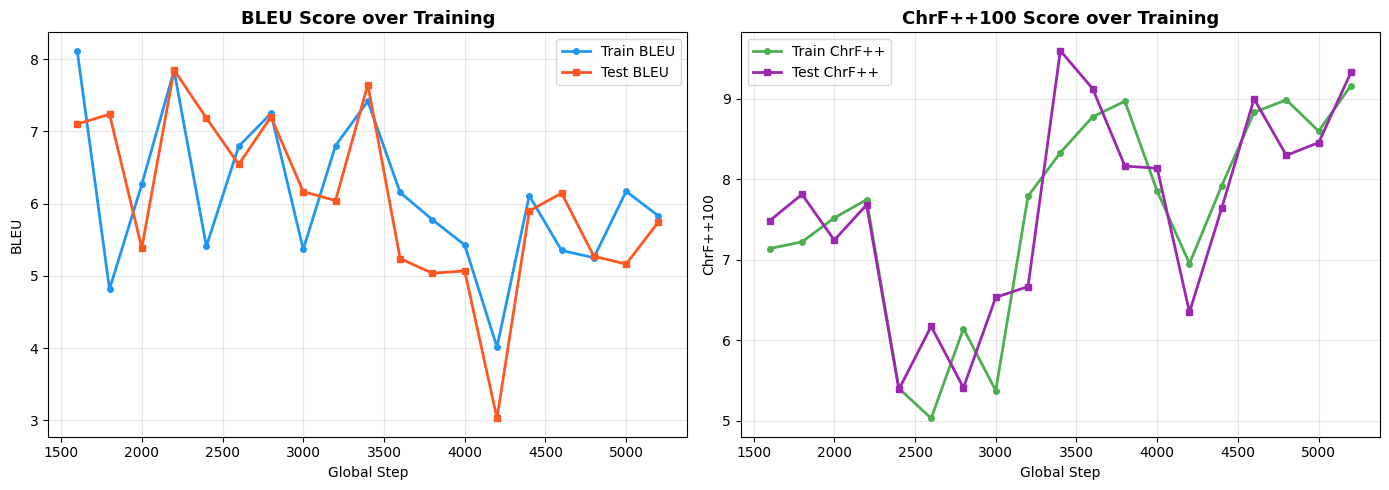

Curves saved → metric_curves.png
Training loop, ChrF++ evaluator, and plot function defined.
See commented example above to run.


In [2]:
# Phase 2: unfreeze encoder, lower LR
model.module.unfreeze_encoder()
optimizer2 = make_optimizer_phase2(model.module)
step = train(model, train_loader, test_ds, train_ds,
             optimizer2, device,
             n_epochs=2, phase2=True, step_offset=step,
             eval_every=200, eval_samples=100,
             metric_history=metric_history)

# Plot curves
plot_metrics(metric_history, save_path="metric_curves.png")

print("Training loop, ChrF++ evaluator, and plot function defined.")
print("See commented example above to run.")
